MAKEMORE_II: CHARACTER LANGUAGE MODEL

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline 

In [3]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
block_size = 3
X, Y = [],[]
for w in words[:5]:
    print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)  

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

Lookup Table C: (Input layer)

In [8]:
C = torch.randn((27, 2))

In [9]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

First Hidden Layer: Tanh

In [10]:
W1 = torch.randn((6,100)) #6 inputs and 100 neurons
b1 = torch.randn(100) #each neuron has a bias

In [11]:
torch.cat([emb[:,0,:], emb[:,1,:],emb[:,2,:]],1).shape #cat concatenates the first 3 embeddings

torch.Size([32, 6])

In [12]:
torch.cat(torch.unbind(emb, 1),1).shape #unbind helps us do the same thing as previous line, but without having to call emb slicing again and again.

torch.Size([32, 6])

In [13]:
emb.view(32,6).shape #View helps us view the same tensor in different dimensions. Therefore this is the same as the previous line, but more efficient as cat creates another memory space, view doesnt

torch.Size([32, 6])

In [14]:
#Therefore
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #tanh layer

In [15]:
h

tensor([[ 0.9995, -0.2468,  0.9855,  ..., -0.7996, -0.8774,  0.1050],
        [ 0.6371, -0.8363,  0.9987,  ...,  0.4330,  0.9963, -0.6773],
        [ 0.7043, -0.8200,  0.3930,  ...,  0.3299,  0.9813, -0.8723],
        ...,
        [ 0.9629, -0.5267,  0.9968,  ..., -0.0250, -0.9863, -0.2410],
        [ 0.6849, -0.6934,  0.9815,  ...,  0.0711,  0.7343,  0.9382],
        [-1.0000, -0.9998,  0.9990,  ...,  0.9942,  1.0000, -0.5300]])

In [16]:
h.shape

torch.Size([32, 100])

Final Layer: Softmax

In [17]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [18]:
logits = h @ W2 + b2

In [19]:
logits.shape

torch.Size([32, 27])

In [20]:
counts = logits.exp()

In [21]:
prob = counts/counts.sum(1,keepdims=True)

In [22]:
prob.shape

torch.Size([32, 27])

In [23]:
prob[0].sum()

tensor(1.)

In [24]:
loss = -prob[torch.arange(32), Y].log().mean()
loss #negative log likelihood

tensor(15.3288)

Neural Network Summary:

Getting Input Data and Labels:

In [25]:
X.shape, Y.shape

(torch.Size([32, 3]), torch.Size([32]))

Getting the parameters: C,W1,b1,W2,b2

In [26]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

Total number of params:

In [27]:
sum(p.nelement() for p in parameters)

3481

Hidden and output Layer: Tanh, Softmax

In [28]:
#Hidden:
emb = C[X] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)

#Output:
logits = h @W2 +b2 #(32,27)
counts = logits.exp()
prob = counts/counts.sum(1,keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.7697)

F.cross_entropy: (loss)

In [29]:
F.cross_entropy(logits,Y)

tensor(17.7697)

Advantages of F.cross_entropy: 1. Better forward pass 2. Better backward pass 3. No Tensor inconsistencies

Training loop:

In [30]:
for p in parameters:
    p.requires_grad=True

In [31]:
for _ in range(1000): 
    #NN:
    #Forward Pass: 
    emb = C[X] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y)
    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

0.25613853335380554


Here params: 3481, and only 32 input examples THEREFORE Overfitting

Training on FULL Dataset:

In [32]:
block_size = 3
X, Y = [],[]
for w in words:
    #print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
       #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)  

In [33]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [34]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [35]:
sum(p.nelement() for p in parameters)

3481

In [36]:
for p in parameters:
    p.requires_grad=True

In [37]:
for _ in range(10): 
    #NN:
    #Forward Pass: 
    emb = C[X] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    for p in parameters:
        p.data += -0.1 * p.grad

19.505229949951172
17.084484100341797
15.776531219482422
14.833338737487793
14.002603530883789
13.253260612487793
12.579916954040527
11.983101844787598
11.470492362976074
11.05185604095459


MiniBatches: (take a part of the dataset to make training faster)

In [38]:
for _ in range(100): 
    #MiniBatch:
    ix = torch.randint(0, X.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[X[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    for p in parameters:
        p.data += -0.1 * p.grad

10.062050819396973
11.470968246459961
10.091692924499512
11.142570495605469
10.429581642150879
11.436166763305664
9.842181205749512
9.328767776489258
8.65915298461914
10.796067237854004
5.623391151428223
8.36864185333252
7.22636079788208
9.181962013244629
7.473668098449707
7.154444694519043
6.196138858795166
8.26601505279541
7.867209434509277
6.348883628845215
4.64060640335083
6.655792713165283
6.065018177032471
6.189492225646973
8.067931175231934
5.661780834197998
6.350636005401611
6.430890083312988
5.908500671386719
7.217287540435791
6.959674835205078
5.58513069152832
5.277514934539795
5.989080429077148
4.206744194030762
4.751290798187256
5.335354328155518
5.00296688079834
4.919460296630859
5.462296962738037
7.328856945037842
5.255613327026367
4.50317907333374
6.494533538818359
6.354100227355957
4.529693603515625
4.168395519256592
5.897263526916504
5.739694595336914
5.077635765075684
5.004984378814697
5.9937334060668945
4.51936149597168
4.935751438140869
3.9601364135742188
3.49453496

Notice how with the minibatch the output came out faster

Optimization:

In [39]:
for _ in range(100): 
    #MiniBatch:
    ix = torch.randint(0, X.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[X[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])

    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

2.868378162384033


Finding good learning rate

In [40]:
lre = torch.linspace(-3,0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [41]:
lri = []
lossi=[]
for i in range(1000): 
    #MiniBatch:
    ix = torch.randint(0, X.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[X[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    lri.append(lre[i])
    lossi.append(loss.item())

#print(loss.item())

2.939500570297241
3.278712272644043
3.1003963947296143
3.114041805267334
3.1338772773742676
4.081719398498535
3.0927019119262695
3.35492205619812
3.1651997566223145
3.5583853721618652
3.650540351867676
3.149378776550293
3.548870325088501
2.9387729167938232
2.965691566467285
3.4772510528564453
3.4663894176483154
2.805436611175537
3.3692853450775146
3.1321680545806885
2.5688233375549316
3.7732784748077393
2.849125862121582
2.703317642211914
3.190601110458374
3.528441905975342
3.406601667404175
3.331723928451538
2.98051118850708
3.3573787212371826
3.945132255554199
3.342637062072754
2.8197131156921387
2.6871631145477295
3.025738477706909
3.3968772888183594
2.6669020652770996
2.565371036529541
4.149161338806152
3.0456604957580566
3.1807405948638916
3.089285373687744
3.002877950668335
2.8933284282684326
2.3235433101654053
3.1595542430877686
3.1718649864196777
3.034501791000366
3.083003520965576
3.0850977897644043
3.1240644454956055
3.2993905544281006
2.7017323970794678
3.8696227073669434
2.

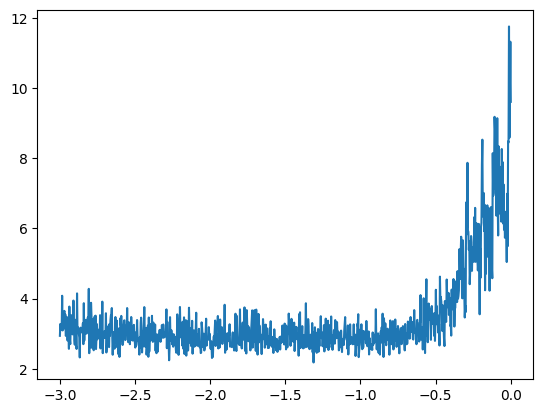

In [42]:
plt.plot(lri, lossi)

Here we can see good learning rate exponent is around -1.0, so good learning rate is 10**-1 which is 0.1

In [43]:
lri = []
lossi=[]
for i in range(10000): 
    #MiniBatch:
    ix = torch.randint(0, X.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[X[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])


    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    #lr = lrs[i]
    lr = 0.1 
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

print(loss.item())

2.54789137840271


In [44]:
emb = C[X] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.4538, grad_fn=<NllLossBackward0>)

Apply Learning Rate Decay: 0.1 -> 0.01

In [45]:
lri = []
lossi=[]
for i in range(10000): 
    #MiniBatch:
    ix = torch.randint(0, X.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[X[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])


    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    #lr = lrs[i]
    lr = 0.01 
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

print(loss.item())  

2.645021438598633


In [46]:
emb = C[X] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Y)
loss        

tensor(2.3689, grad_fn=<NllLossBackward0>)

Splitting up the data into train,test,validate:

In [47]:
#train-80%, test-10%, validate-10%

def build_dataset(words):
    block_size = 3
    X, Y = [],[]
    for w in words:
        #print(w)
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)  
    print(X.shape,Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [48]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [49]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [50]:
sum(p.nelement() for p in parameters)

3481

In [51]:
for p in parameters:
    p.requires_grad=True

In [52]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [53]:
lri = []
lossi=[]
for i in range(10000): 
    #MiniBatch:
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[Xtr[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Ytr[ix])


    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    #lr = lrs[i]
    lr = 0.01 
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

print(loss.item())  

3.0558249950408936


In [54]:
emb = C[Xtr] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.5712, grad_fn=<NllLossBackward0>)

In [55]:
emb = C[Xdev] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.5652, grad_fn=<NllLossBackward0>)

Currently same loss for training data and validation data means , the NN is underfitting, therefore to solve we increase the number of neurons in the hidden layer from 100 -> 300

In [56]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [57]:
sum(p.nelement() for p in parameters)

3481

In [58]:
for p in parameters:
    p.requires_grad=True

In [59]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [ ]:
lri = []
lossi=[]

for i in range(10000): 
    #MiniBatch:
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[Xtr[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Ytr[ix])


    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    #lr = lrs[i]
    lr = 0.01 
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

print(loss.item())  

2.047989845275879


In [62]:
emb = C[Xtr] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.4484, grad_fn=<NllLossBackward0>)

Experiment: larger hidden layer

In [63]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,300), generator=g)
b1 = torch.randn(300,generator=g)
W2 = torch.randn((300,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [64]:
sum(p.nelement() for p in parameters)

10281

In [65]:
for p in parameters:
    p.requires_grad=True

In [66]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [80]:
lri = []
lossi=[]
stepi=[]
for i in range(30000): 
    #MiniBatch:
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[Xtr[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Ytr[ix])


    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    #lr = lrs[i]
    lr = 0.01 
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.item())

#print(loss.item())  

In [81]:
emb = C[Xtr] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2416, grad_fn=<NllLossBackward0>)

In [82]:
emb = C[Xdev] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2521, grad_fn=<NllLossBackward0>)